# 03 — Exploration

Avant de modéliser : qui sont ces ~5 400 personnes, comment la cible se répartit selon
la démographie, et est-ce que les apports alimentaires diffèrent visiblement entre cas et
témoins ?

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 60)
from src import plotting
from src.config import RESULTS_DIR
df = pd.read_parquet(ROOT / 'data' / 'processed' / 'analytique.parquet')
df = df[df['cible'].notna()].copy()
print(df.shape)

(5405, 55)


In [2]:
desc = df.groupby("cible").agg(
    n=("age", "size"),
    age_moyen=("age", "mean"),
    part_femmes=("sexe", lambda s: (s == "Femme").mean()),
    revenu_median=("ratio_revenu", "median"),
    kcal=("energie_kcal", "median"),
    fibres=("fibres_g", "median"),
    sucres=("sucres_g", "median"),
    sodium=("sodium_mg", "median"),
    activite=("activite_met_min_sem", "median"),
).round(2)
desc.T

cible,0.0,1.0
n,3647.00,1758.00
age_moyen,44.02,52.51
part_femmes,0.52,0.53
revenu_median,2.26,2.05
kcal,1961.25,1921.00
fibres,15.45,14.95
sucres,93.46,93.94
sodium,3203.00,3126.50
activite,240.00,0.00


Rien de spectaculaire côté alimentation à ce stade : les médianes de fibres, sucres,
sodium sont proches entre les deux groupes. La différence nette est ailleurs — l'âge. Les
personnes avec syndrome métabolique sont en moyenne bien plus âgées. Ça va peser lourd
dans les modèles, et il faudra regarder l'apport des variables alimentaires *à âge
donné*.

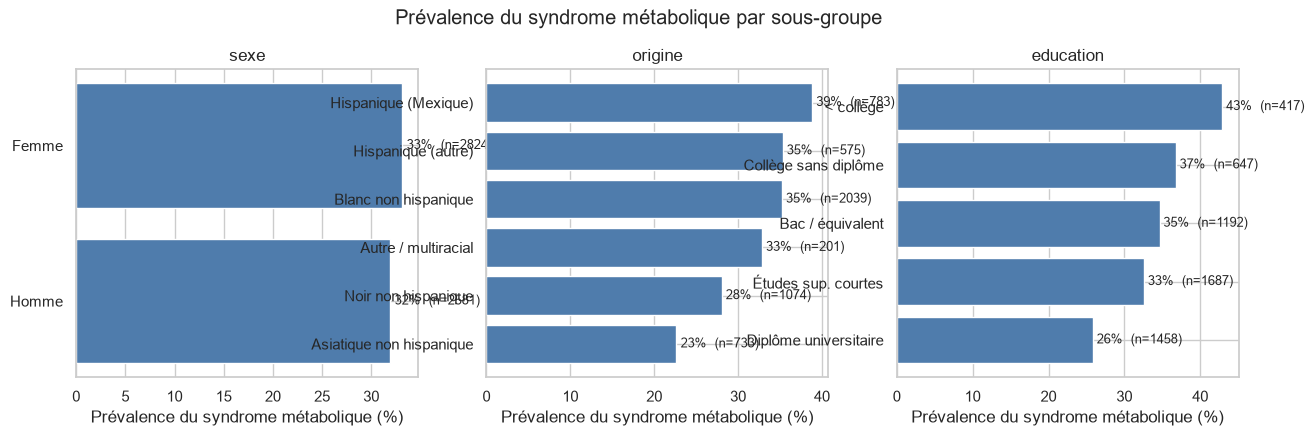

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["sexe", "origine", "education"]):
    plotting.prevalence_par_groupe(df, col, ax=ax)
    ax.set_title(col)
fig.suptitle("Prévalence du syndrome métabolique par sous-groupe", y=1.03)
plotting.save(fig, "03_prevalence_sous_groupes")
plt.show()

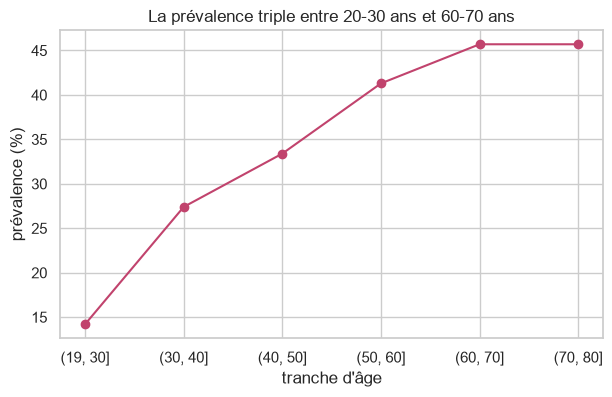

age
(19, 30]    14.2
(30, 40]    27.4
(40, 50]    33.4
(50, 60]    41.3
(60, 70]    45.7
(70, 80]    45.7
Name: cible, dtype: float64

In [4]:
tranche = pd.cut(df["age"], [19, 30, 40, 50, 60, 70, 80], right=True)
prev_age = df.groupby(tranche, observed=True)["cible"].mean().mul(100).round(1)
fig, ax = plt.subplots(figsize=(7, 4))
prev_age.plot(marker="o", ax=ax, color=plotting.PALETTE["positif"])
ax.set(xlabel="tranche d'âge", ylabel="prévalence (%)",
       title="La prévalence triple entre 20-30 ans et 60-70 ans")
plotting.save(fig, "03_prevalence_age")
plt.show()
prev_age

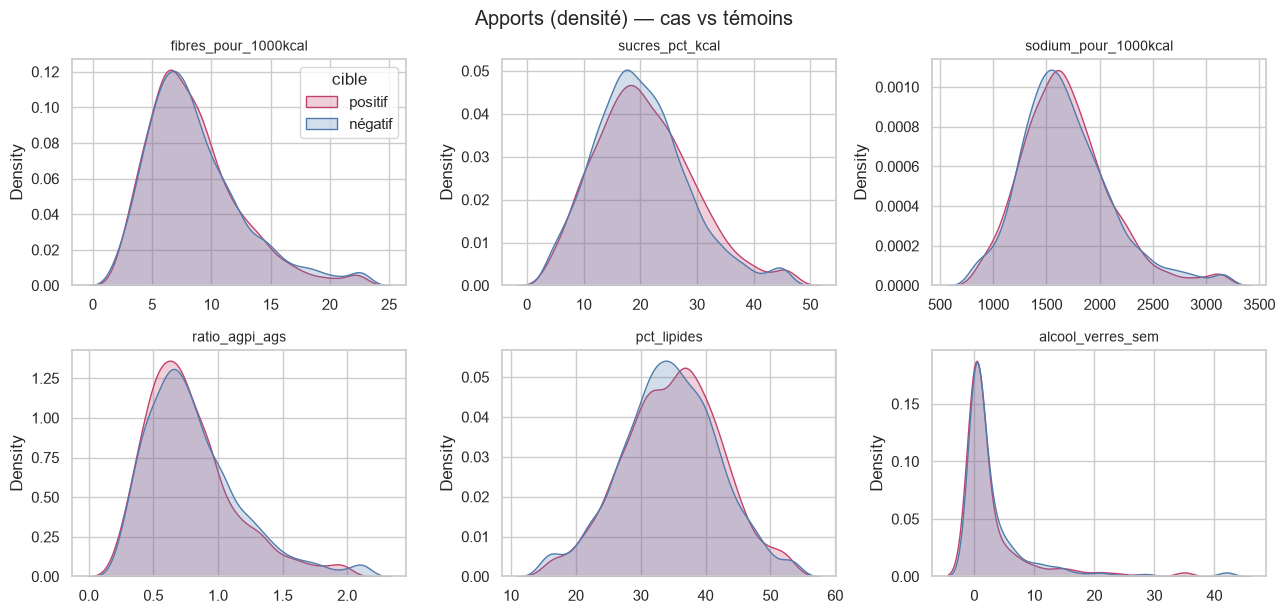

In [5]:
nutriments = ["fibres_pour_1000kcal", "sucres_pct_kcal", "sodium_pour_1000kcal",
              "ratio_agpi_ags", "pct_lipides", "alcool_verres_sem"]
fig = plotting.distributions_nutriments(df, nutriments)
fig.suptitle("Apports (densité) — cas vs témoins", y=1.02)
plotting.save(fig, "03_distributions_nutriments")
plt.show()

Les distributions d'apports se chevauchent presque complètement. Visuellement, l'alimentation
déclarée ne sépare pas les cas des témoins. C'est un signal faible — cohérent avec le fait
que les rappels 24 h sont bruités (une à deux journées seulement) et sujets à sous-déclaration.
On verra si un modèle arrive quand même à en tirer quelque chose une fois l'âge et le sexe
pris en compte.

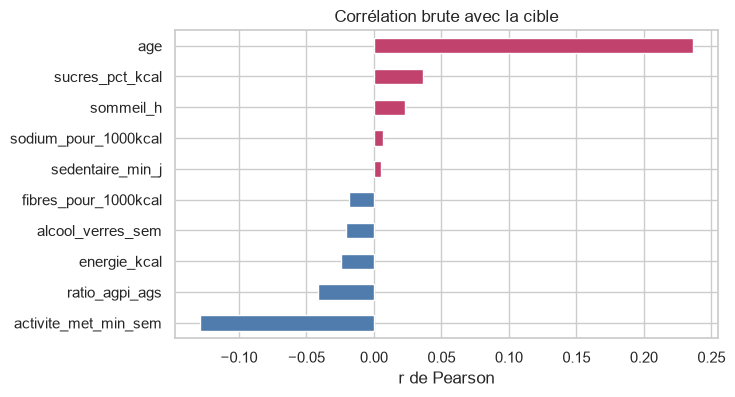

In [6]:
num = ["age", "energie_kcal", "fibres_pour_1000kcal", "sucres_pct_kcal",
       "sodium_pour_1000kcal", "ratio_agpi_ags", "activite_met_min_sem",
       "sedentaire_min_j", "alcool_verres_sem", "sommeil_h"]
corr = df[num + ["cible"]].corr(numeric_only=True)["cible"].drop("cible").sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot(kind="barh", ax=ax, color=[plotting.PALETTE["négatif"] if v < 0 else plotting.PALETTE["positif"] for v in corr])
ax.set(title="Corrélation brute avec la cible", xlabel="r de Pearson")
plotting.save(fig, "03_correlations")
plt.show()

Corrélations brutes toutes faibles (|r| < 0,15). La sédentarité et l'âge (déjà connu) vont
dans le sens attendu ; l'activité physique et le sommeil protègent légèrement. À prendre
avec prudence : ce sont des corrélations non ajustées.

*Sur les pondérations d'enquête :* NHANES fournit des poids (`WTMEC2YR`, strates, PSU) pour
estimer des prévalences représentatives de la population américaine. Je les garde pour le
descriptif mais **pas pour la modélisation** : l'objectif ici est de prédire au niveau
individuel, pas d'estimer un paramètre de population. Une analyse pondérée complète
(avec le plan de sondage) serait le prolongement naturel côté épidémiologie.